# Welcome to Colab!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read dataset

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

seeing the variables names

In [4]:
print(df.columns)

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')


In [19]:
df.head(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74.0,1,11.1,8,88.9,2,22.2,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79.0,9,17.6,42,82.4,33,64.7,40,78.4
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,0,51,100,44,86.3,50,98
11,01M184,P.S. 184m Shuang Wen,K-8,Living Environment,2017,55,83.9,1,1.8,54,98.2,43,78.2,na,na
12,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2015,23,62.9,14,60.9,9,39.1,0,0,2,8.7


Cleanning data

In [12]:
# Convert Mean Score to numeric
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')

# Drop missing Mean Score values
df = df.dropna(subset=['Mean Score'])

Average P.S188 mean Score

In [13]:
school = df[df['School Name'] == 'P.S. 188 The Island School']

In [8]:
school_avg = school['Mean Score'].median()

entire schools average

In [9]:
overall_avg = df['Mean Score'].median()

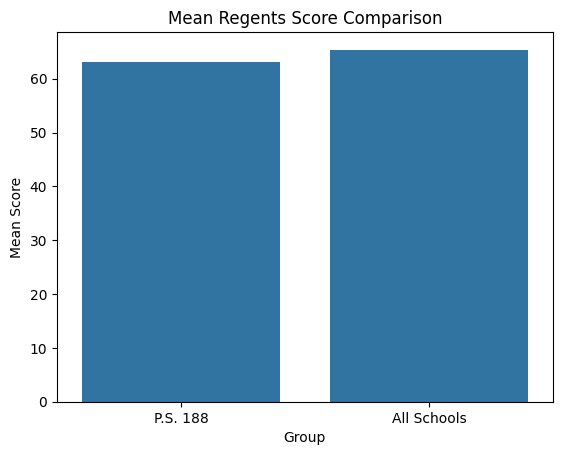

In [16]:
comparison = pd.DataFrame({
    'Group': ['P.S. 188', 'All Schools'],
    'Mean Score': [school_avg, overall_avg]
})

sns.barplot(data=comparison, x='Group', y='Mean Score')
plt.title('Mean Regents Score Comparison')
plt.show()

P.S. 188’s average Regents score is slightly lower than the average for all schools. This shows that the school performs close to the overall average but is a little below it.


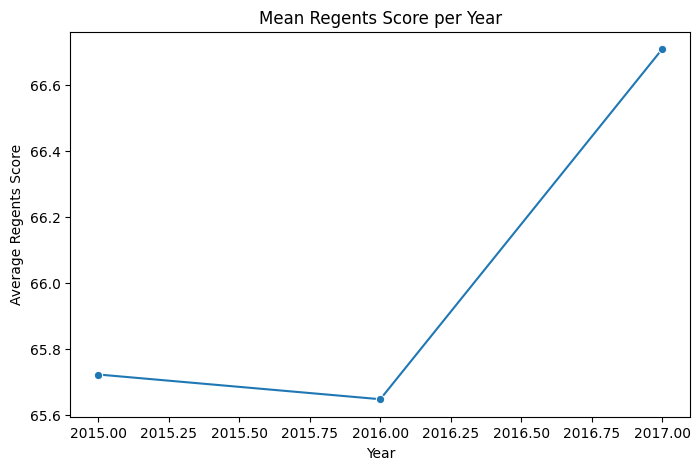

In [23]:

# Calculate mean Regents score per year
mean_scores = df.groupby('Year')['Mean Score'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.lineplot(data=mean_scores, x='Year', y='Mean Score', marker='o')

plt.title('Mean Regents Score per Year')
plt.xlabel('Year')
plt.ylabel('Average Regents Score')

plt.show()